Using deterministic seed: 123
Artifacts will be saved to: /content/stat_arb_project_outputs

Price sample:
     Asset_0    Asset_1    Asset_2    Asset_3    Asset_4    Asset_5  \
0  54.672531  54.672531  65.174087  66.136674  66.969642  65.926999   
1  55.990671  54.380421  65.210878  65.447775  67.531246  65.991359   
2  56.058459  54.428089  65.659864  65.436606  70.002657  66.807536   
3  55.355589  53.920473  65.634077  65.816269  69.939553  67.544201   
4  55.471499  54.452976  67.095382  65.354917  69.534838  68.009012   

     Asset_6    Asset_7  t  
0  65.459963  65.507494  0  
1  65.197655  64.738872  1  
2  67.139843  66.659043  2  
3  65.685624  67.769077  3  
4  66.748146  67.768522  4  

Backtest sample:
     t  asset_y  asset_x      beta    spread    zscore  position  raw_return  \
0  200  Asset_1  Asset_5  0.475095  0.016268  0.867020      -1.0   -0.000000   
1  201  Asset_1  Asset_5  0.475095  0.017821  0.911101      -1.0   -0.001553   
2  202  Asset_1  Asset_5  0.475095

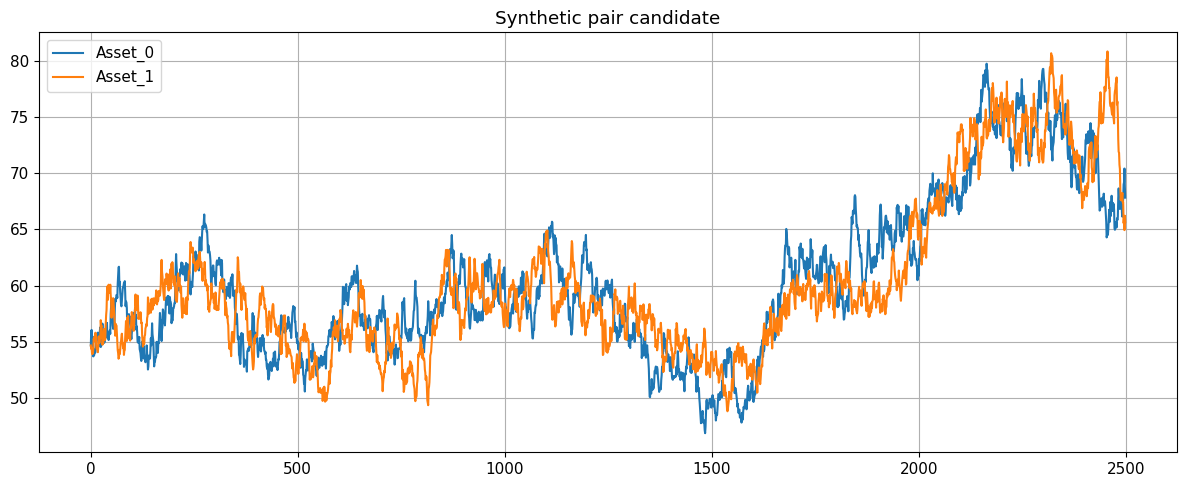

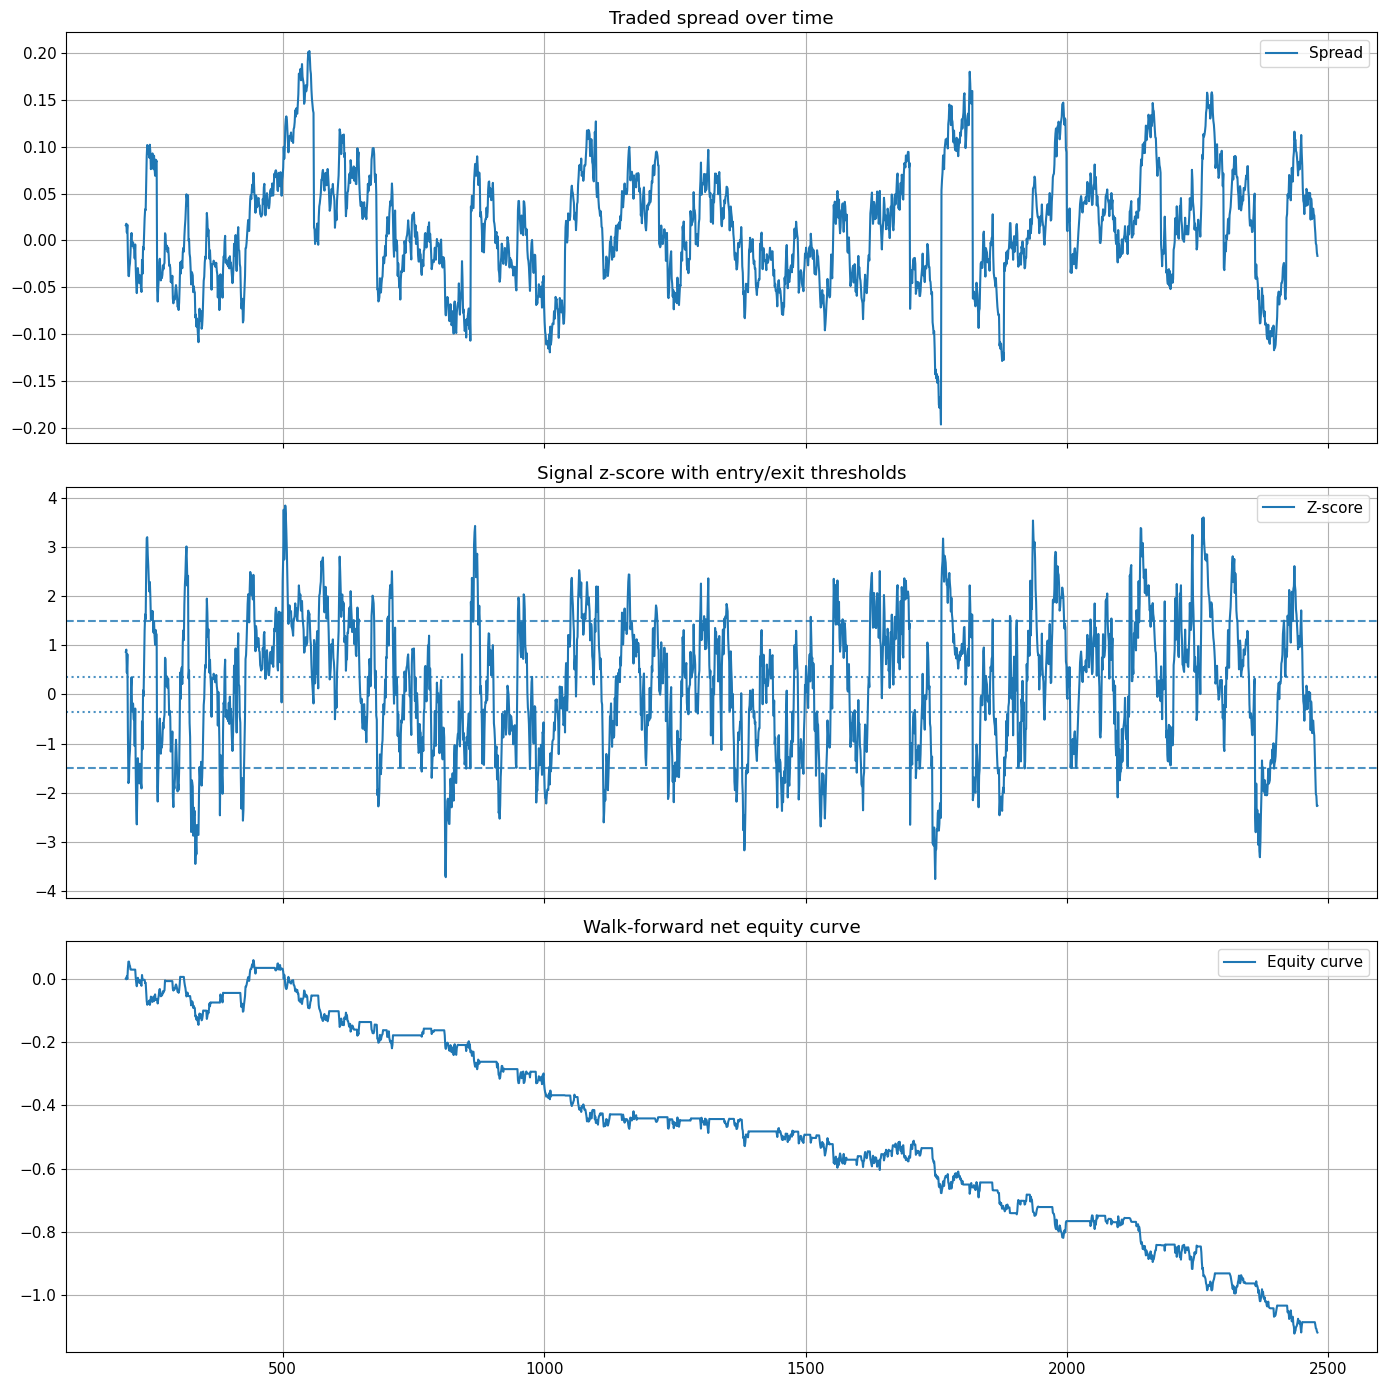

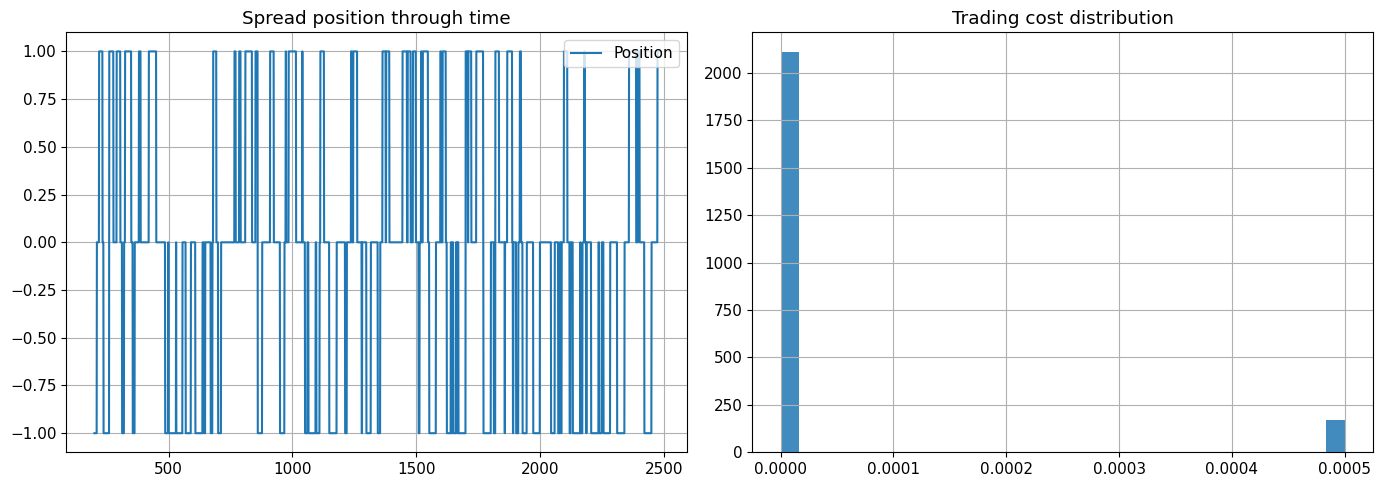


Selected pairs across walk-forward windows:
   asset_y  asset_x     alpha      beta  spread_std  half_life     score
0  Asset_1  Asset_5  2.008812  0.475095    0.020884   3.714734  0.021660
1  Asset_2  Asset_4  5.105628 -0.202582    0.019436   4.137145  0.020240
2  Asset_1  Asset_4  2.782784  0.291840    0.025207   6.863100  0.026937
3  Asset_3  Asset_5  1.990427  0.551911    0.021535   5.045098  0.022622
4  Asset_3  Asset_5  2.558552  0.415085    0.023334   5.902082  0.024711
5  Asset_3  Asset_5  2.018490  0.545615    0.032568  10.253528  0.035907
6  Asset_0  Asset_7  3.049972  0.206441    0.025645   7.250604  0.027505
7  Asset_0  Asset_5  2.538933  0.344794    0.030091  10.356581  0.033207
8  Asset_4  Asset_5  3.014747  0.355360    0.029708   7.487656  0.031933
9  Asset_4  Asset_5  2.657082  0.439188    0.030379   6.915382  0.032479

Summary table:
                        metric        value
0                 final_equity    -1.117715
1              mean_net_return    -0.000490
2   

In [1]:
import math
import json
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY AND OUTPUT SETUP
# ============================================================
SEED = 123
rng = np.random.default_rng(SEED)

OUTPUT_DIR = Path("stat_arb_project_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print(f"Using deterministic seed: {SEED}")
print(f"Artifacts will be saved to: {OUTPUT_DIR.resolve()}")


# ============================================================
# 2. CONFIGURATION
# ============================================================
@dataclass
class DataConfig:
    n_steps: int = 2500
    n_assets: int = 8
    market_vol: float = 0.008
    sector_vol: float = 0.006
    idio_vol: float = 0.01
    spread_reversion: float = 0.06
    spread_vol: float = 0.02


@dataclass
class SignalConfig:
    formation_window: int = 200
    trading_window: int = 60
    z_lookback: int = 60
    entry_z: float = 1.5
    exit_z: float = 0.35
    max_holding_period: int = 30


@dataclass
class CostConfig:
    linear_cost_bps: float = 3.0
    slippage_bps: float = 2.0


data_cfg = DataConfig()
signal_cfg = SignalConfig()
cost_cfg = CostConfig()


# ============================================================
# 3. UTILITY FUNCTIONS
# ============================================================
def sharpe_ratio(returns: np.ndarray, annualization_factor: float = 252.0) -> float:
    std = np.std(returns)
    if std < 1e-12:
        return 0.0
    return float((np.mean(returns) / std) * np.sqrt(annualization_factor))


def max_drawdown(equity_curve: np.ndarray) -> float:
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = equity_curve - running_max
    return float(drawdown.min())


def ols_beta(y: np.ndarray, x: np.ndarray) -> tuple[float, float]:
    x_mean = x.mean()
    y_mean = y.mean()
    cov = np.mean((x - x_mean) * (y - y_mean))
    var = np.mean((x - x_mean) ** 2)
    beta = cov / max(var, 1e-12)
    alpha = y_mean - beta * x_mean
    return alpha, beta


def half_life_of_mean_reversion(spread: np.ndarray) -> float:
    s = spread[:-1]
    ds = np.diff(spread)

    if len(s) < 10:
        return np.nan

    a, b = ols_beta(ds, s)
    if b >= 0:
        return np.inf
    return float(-np.log(2) / b)


def ensure_serializable(x):
    if isinstance(x, dict):
        return {k: ensure_serializable(v) for k, v in x.items()}
    if isinstance(x, list):
        return [ensure_serializable(v) for v in x]
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, np.generic):
        return x.item()
    return x


# ============================================================
# 4. SYNTHETIC MULTI-ASSET UNIVERSE
# ============================================================
def generate_synthetic_universe(cfg: DataConfig, rng: np.random.Generator) -> pd.DataFrame:
    """
    Generate a synthetic universe of prices.
    Asset_0 and Asset_1 form a designed mean-reverting pair.
    """
    n = cfg.n_steps
    k = cfg.n_assets

    market_factor = np.cumsum(rng.normal(0, cfg.market_vol, size=n))
    sector_factor = np.cumsum(rng.normal(0, cfg.sector_vol, size=n))

    # Mean-reverting spread for the pair
    spread = np.zeros(n)
    for t in range(1, n):
        spread[t] = (
            (1 - cfg.spread_reversion) * spread[t - 1]
            + rng.normal(0, cfg.spread_vol)
        )

    base_anchor = np.cumsum(rng.normal(0, cfg.market_vol * 0.7, size=n))

    prices = {}

    log_p0 = base_anchor + spread / 2 + 0.3 * market_factor
    log_p1 = base_anchor - spread / 2 + 0.3 * market_factor

    prices["Asset_0"] = np.exp(log_p0 + 4.0)
    prices["Asset_1"] = np.exp(log_p1 + 4.0)

    for i in range(2, k):
        beta_m = rng.uniform(0.6, 1.3)
        beta_s = rng.uniform(-0.5, 0.9)
        idio = np.cumsum(rng.normal(0, cfg.idio_vol, size=n))
        log_pi = 4.2 + beta_m * market_factor + beta_s * sector_factor + idio
        prices[f"Asset_{i}"] = np.exp(log_pi)

    df = pd.DataFrame(prices)
    df["t"] = np.arange(n)
    return df


price_df = generate_synthetic_universe(data_cfg, rng)
print("\nPrice sample:")
print(price_df.head())


# ============================================================
# 5. PAIR SELECTION
# ============================================================
def select_best_pair(price_df: pd.DataFrame, formation_start: int, formation_end: int) -> dict:
    """
    Select the best pair using:
    - log-price regression
    - residual spread variance
    - half-life penalty
    """
    asset_cols = [c for c in price_df.columns if c.startswith("Asset_")]
    formation_prices = price_df.loc[formation_start:formation_end, asset_cols]
    log_prices = np.log(formation_prices)

    best = None

    for i in range(len(asset_cols)):
        for j in range(i + 1, len(asset_cols)):
            a = asset_cols[i]
            b = asset_cols[j]

            y = log_prices[a].values
            x = log_prices[b].values

            alpha, beta = ols_beta(y, x)
            spread = y - (alpha + beta * x)

            hl = half_life_of_mean_reversion(spread)
            spread_std = np.std(spread)

            score = spread_std
            if np.isfinite(hl):
                score *= (1 + 0.01 * hl)

            candidate = {
                "asset_y": a,
                "asset_x": b,
                "alpha": float(alpha),
                "beta": float(beta),
                "spread_std": float(spread_std),
                "half_life": float(hl),
                "score": float(score)
            }

            if (best is None) or (candidate["score"] < best["score"]):
                best = candidate

    return best


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================
def build_spread_features(price_df: pd.DataFrame, pair_info: dict, z_lookback: int) -> pd.DataFrame:
    y = np.log(price_df[pair_info["asset_y"]].values)
    x = np.log(price_df[pair_info["asset_x"]].values)

    spread = y - (pair_info["alpha"] + pair_info["beta"] * x)

    feat = pd.DataFrame({
        "t": price_df["t"].values,
        "spread": spread
    })

    feat["spread_mean"] = feat["spread"].rolling(z_lookback).mean()
    feat["spread_std"] = feat["spread"].rolling(z_lookback).std()
    feat["zscore"] = (feat["spread"] - feat["spread_mean"]) / feat["spread_std"]

    return feat


# ============================================================
# 7. SIGNAL GENERATION
# ============================================================
def generate_positions(
    feature_df: pd.DataFrame,
    entry_z: float,
    exit_z: float,
    max_holding_period: int
) -> pd.DataFrame:
    """
    Position rules:
    +1 = long spread
    -1 = short spread
     0 = flat
    """
    pos = np.zeros(len(feature_df))
    current_pos = 0
    holding_days = 0

    for t in range(len(feature_df)):
        z = feature_df.loc[t, "zscore"]

        if np.isnan(z):
            pos[t] = 0
            continue

        if current_pos == 0:
            if z < -entry_z:
                current_pos = 1
                holding_days = 0
            elif z > entry_z:
                current_pos = -1
                holding_days = 0
        else:
            holding_days += 1
            if abs(z) < exit_z or holding_days >= max_holding_period:
                current_pos = 0
                holding_days = 0

        pos[t] = current_pos

    out = feature_df.copy()
    out["position"] = pos
    return out


# ============================================================
# 8. WALK-FORWARD BACKTEST
# ============================================================
def run_walk_forward_backtest(
    price_df: pd.DataFrame,
    signal_cfg: SignalConfig,
    cost_cfg: CostConfig
) -> tuple[pd.DataFrame, list]:
    """
    Walk-forward protocol:
    - estimate on formation window
    - trade next window
    - roll forward
    """
    results = []
    metadata = []

    n = len(price_df)
    start = 0

    while True:
        formation_start = start
        formation_end = formation_start + signal_cfg.formation_window - 1
        trading_start = formation_end + 1
        trading_end = trading_start + signal_cfg.trading_window - 1

        if trading_end >= n:
            break

        pair = select_best_pair(price_df, formation_start, formation_end)

        combined_start = max(0, formation_start)
        combined_end = trading_end
        window_df = price_df.loc[combined_start:combined_end].reset_index(drop=True)

        feat = build_spread_features(window_df, pair, signal_cfg.z_lookback)
        sig = generate_positions(
            feat,
            entry_z=signal_cfg.entry_z,
            exit_z=signal_cfg.exit_z,
            max_holding_period=signal_cfg.max_holding_period
        )

        trading_mask = (window_df["t"] >= trading_start) & (window_df["t"] <= trading_end)
        trade_df = window_df.loc[trading_mask].copy().reset_index(drop=True)
        trade_sig = sig.loc[trading_mask].copy().reset_index(drop=True)

        y = np.log(trade_df[pair["asset_y"]].values)
        x = np.log(trade_df[pair["asset_x"]].values)

        ret_y = np.diff(y, prepend=y[0])
        ret_x = np.diff(x, prepend=x[0])

        # Spread return
        raw_spread_ret = trade_sig["position"].values * (ret_y - pair["beta"] * ret_x)

        # Transaction costs from turnover
        position_change = np.abs(np.diff(trade_sig["position"].values, prepend=0))
        total_cost_per_change = (cost_cfg.linear_cost_bps + cost_cfg.slippage_bps) * 1e-4
        trading_cost = position_change * total_cost_per_change

        net_ret = raw_spread_ret - trading_cost

        chunk = pd.DataFrame({
            "t": trade_df["t"].values,
            "asset_y": pair["asset_y"],
            "asset_x": pair["asset_x"],
            "beta": pair["beta"],
            "spread": trade_sig["spread"].values,
            "zscore": trade_sig["zscore"].values,
            "position": trade_sig["position"].values,
            "raw_return": raw_spread_ret,
            "trading_cost": trading_cost,
            "net_return": net_ret,
            "formation_start": formation_start,
            "formation_end": formation_end,
            "trading_start": trading_start,
            "trading_end": trading_end
        })

        results.append(chunk)
        metadata.append(pair)

        start += signal_cfg.trading_window

    backtest_df = pd.concat(results, ignore_index=True)
    backtest_df["equity_curve"] = backtest_df["net_return"].cumsum()
    return backtest_df, metadata


backtest_df, pair_metadata = run_walk_forward_backtest(price_df, signal_cfg, cost_cfg)
print("\nBacktest sample:")
print(backtest_df.head())


# ============================================================
# 9. METRICS
# ============================================================
def compute_backtest_metrics(backtest_df: pd.DataFrame) -> dict:
    returns = backtest_df["net_return"].values
    raw_returns = backtest_df["raw_return"].values
    equity = backtest_df["equity_curve"].values
    active_mask = backtest_df["position"] != 0

    metrics = {
        "final_equity": float(equity[-1]),
        "mean_net_return": float(np.mean(returns)),
        "std_net_return": float(np.std(returns)),
        "sharpe_like": float(sharpe_ratio(returns)),
        "max_drawdown": float(max_drawdown(equity)),
        "gross_return_sum": float(np.sum(raw_returns)),
        "net_return_sum": float(np.sum(returns)),
        "cost_sum": float(backtest_df["trading_cost"].sum()),
        "cost_as_pct_of_gross": float(
            backtest_df["trading_cost"].sum() / max(abs(np.sum(raw_returns)), 1e-12)
        ),
        "avg_abs_zscore_when_active": float(np.mean(np.abs(backtest_df.loc[active_mask, "zscore"])))
        if active_mask.any() else 0.0,
        "num_active_periods": int(active_mask.sum()),
        "turnover": float(np.abs(np.diff(backtest_df["position"].values, prepend=0)).sum())
    }
    return metrics


metrics = compute_backtest_metrics(backtest_df)
print("\n=== STAT ARB PROJECT METRICS ===")
for k, v in metrics.items():
    print(f"{k:28s}: {v}")


# ============================================================
# 10. SAVE OUTPUTS
# ============================================================
backtest_df.to_csv(OUTPUT_DIR / "stat_arb_backtest_timeseries.csv", index=False)

with open(OUTPUT_DIR / "stat_arb_metrics.json", "w") as f:
    json.dump(ensure_serializable(metrics), f, indent=2)

with open(OUTPUT_DIR / "selected_pairs.json", "w") as f:
    json.dump(ensure_serializable(pair_metadata), f, indent=2)

print("\nSaved files:")
print("-", OUTPUT_DIR / "stat_arb_backtest_timeseries.csv")
print("-", OUTPUT_DIR / "stat_arb_metrics.json")
print("-", OUTPUT_DIR / "selected_pairs.json")


# ============================================================
# 11. PLOTS
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(price_df["t"], price_df["Asset_0"], label="Asset_0")
ax.plot(price_df["t"], price_df["Asset_1"], label="Asset_1")
ax.set_title("Synthetic pair candidate")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "synthetic_pair_view.png", dpi=160)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

axes[0].plot(backtest_df["t"], backtest_df["spread"], label="Spread")
axes[0].set_title("Traded spread over time")
axes[0].legend()

axes[1].plot(backtest_df["t"], backtest_df["zscore"], label="Z-score")
axes[1].axhline(signal_cfg.entry_z, linestyle="--", alpha=0.8)
axes[1].axhline(-signal_cfg.entry_z, linestyle="--", alpha=0.8)
axes[1].axhline(signal_cfg.exit_z, linestyle=":", alpha=0.8)
axes[1].axhline(-signal_cfg.exit_z, linestyle=":", alpha=0.8)
axes[1].set_title("Signal z-score with entry/exit thresholds")
axes[1].legend()

axes[2].plot(backtest_df["t"], backtest_df["equity_curve"], label="Equity curve")
axes[2].set_title("Walk-forward net equity curve")
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stat_arb_main_plots.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(backtest_df["t"], backtest_df["position"], label="Position")
axes[0].set_title("Spread position through time")
axes[0].legend()

axes[1].hist(backtest_df["trading_cost"], bins=30, alpha=0.85)
axes[1].set_title("Trading cost distribution")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stat_arb_cost_diagnostics.png", dpi=160)
plt.show()


# ============================================================
# 12. PAIR SELECTION AND SUMMARY TABLES
# ============================================================
pair_selection_df = pd.DataFrame(pair_metadata)
print("\nSelected pairs across walk-forward windows:")
print(pair_selection_df.head(10))

summary_df = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})
print("\nSummary table:")
print(summary_df)